In [1]:
from src.dataset import load_dataset
from regression.probabilistic_rf_scoring import plot_ranked_pdfs
from regression.probabilistic_rf_scoring import fit_rank_pdfs_loglik, plot_pdf_with_true_target
from regression.PolynomialRegressor.polynomial_regression import PolynomialRegression
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [3]:
TRAIN_PATH_FULL="../../../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/polynomial_regression/model_margin/"
MODEL_PATH="polynomial_regression_model_margin.pkl"
RESIDUI_CSV="residui.csv"
TARGET_COL = "trq_margin"
FEUTURE=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
DEGREE = {1,2,3}
ITERATIONS = 1000

In [4]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)


X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test = test_df[TARGET_COL].values


Degree  1
MAE: 1.7576857246654
MSE: 5.4989308877994985
RMSE: 2.3449799333468717
R²: 0.9721896774692983


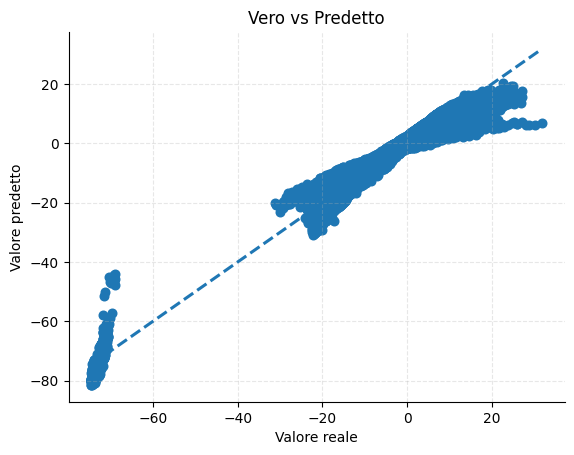


Degree  2
MAE: 0.3304181423299561
MSE: 0.2714167788927091
RMSE: 0.5209767546567784
R²: 0.9986273353284003


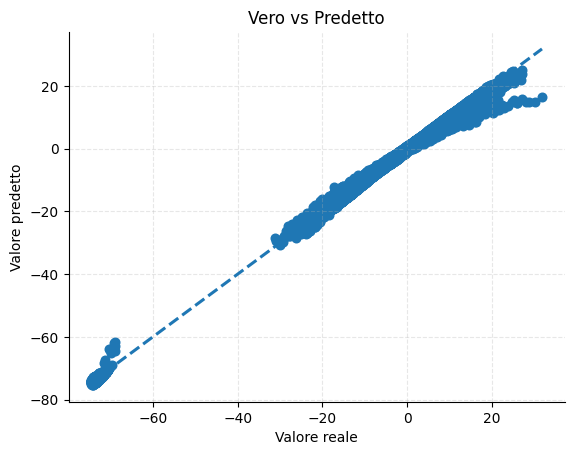


Degree  3
MAE: 0.08875461034264077
MSE: 0.02508650115902969
RMSE: 0.15838718748380404
R²: 0.9998731273946455


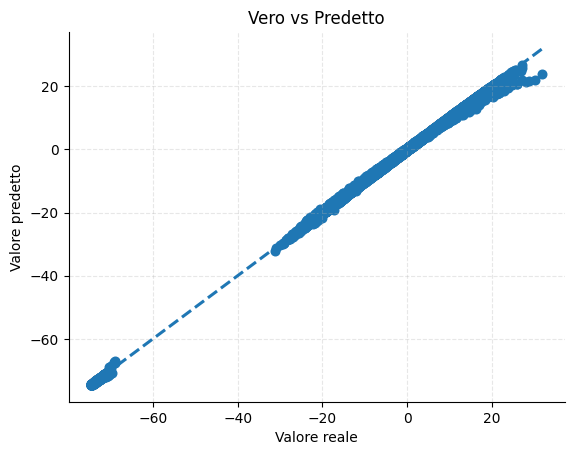

In [5]:
for degree in DEGREE:
    model = PolynomialRegression(degree=degree)
    model.fit(X_train, y_train)
    print("\n"+"Degree ", degree)
    model.evaluate_regression(X_test, y_test)

    y_pred = model.predict(X_test)

    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    plt.xlabel("Valore reale")
    plt.ylabel("Valore predetto")
    plt.title("Vero vs Predetto")
    plt.show()

In [ ]:
train_full=load_dataset(TRAIN_PATH_FULL)
X_train_full = train_full[FEUTURE].values
y_train_full = train_full[TARGET_COL].values

model_try = PolynomialRegression(degree=2)
best_degree,a,b=model_try.tune_degree(X_train_full, y_train_full, degrees=DEGREE, cv=5, metric="rmse")

In [6]:
model = PolynomialRegression(degree=3)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    model= joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
  model.fit(X_train, y_train)
  os.makedirs(OUTPUT_PATH, exist_ok=True)
  joblib.dump(model, OUTPUT_PATH + MODEL_PATH)

In [7]:
if os.path.exists( not OUTPUT_PATH+RESIDUI_CSV):
    model.compute_residuals(X_train,y_train,path=OUTPUT_PATH)

In [8]:
residui = load_dataset(OUTPUT_PATH + RESIDUI_CSV)

test_row = test_df.iloc[1231]
test_x = test_row[FEUTURE].to_frame().T
test_y_true =test_row[TARGET_COL]
trq_margin_pred = model.predict(test_x)[0]

rows = []
for m in range(ITERATIONS):
    residual = residui.sample(n=1)["residual"].iloc[0]
    rows.append({"trq_margin_probability": trq_margin_pred + residual})

distribution = pd.DataFrame(rows)
distribution.head()

,trq_margin_probability
0,10.946046
1,10.952775
2,10.967488
3,10.929946
4,10.981416


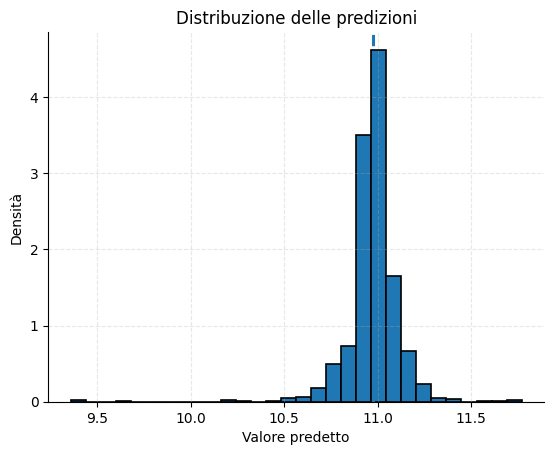

In [9]:
plt.figure()
plt.hist(distribution["trq_margin_probability"], bins=30, density=True)
plt.axvline(trq_margin_pred, linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()

In [10]:
ranking,best= fit_rank_pdfs_loglik(distribution["trq_margin_probability"])


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) laplace      | loglik=745.70
02) cauchy       | loglik=733.15
03) logistic     | loglik=688.53
04) t            | loglik=606.52
05) beta         | loglik=500.18
06) norm         | loglik=465.54
07) lognorm      | loglik=465.54
08) nakagami     | loglik=465.26
09) f            | loglik=463.91
10) weibull_min  | loglik=414.91
11) chi2         | loglik=392.28
12) betaprime    | loglik=378.55
13) gamma        | loglik=94.41
14) gumbel_r     | loglik=-208.71
15) powerlaw     | loglik=-579.54
16) erlang       | loglik=-615.33
17) rayleigh     | loglik=-811.54
18) uniform      | loglik=-881.09
19) expon        | loglik=-1482.36
20) pareto       | loglik=-1482.36


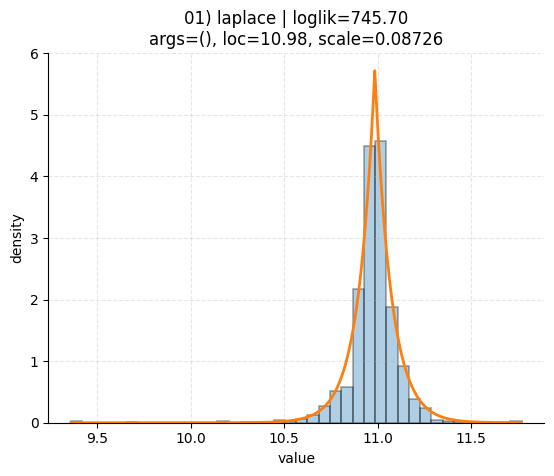

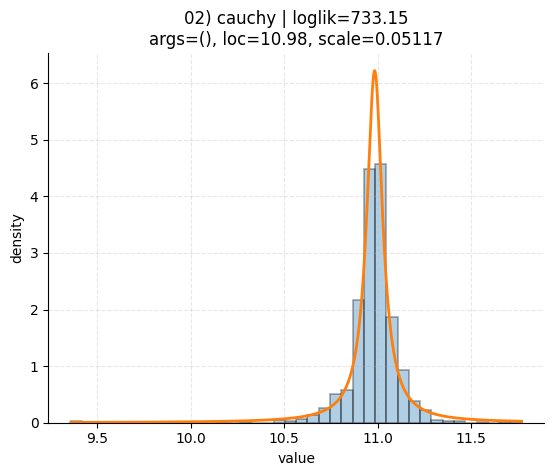

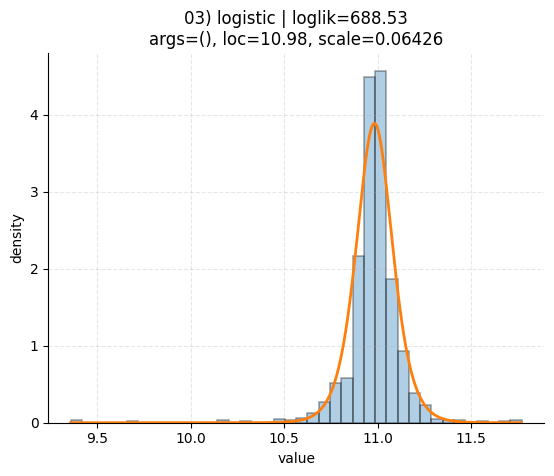

In [11]:
plot_ranked_pdfs(ranking,distribution["trq_margin_probability"])

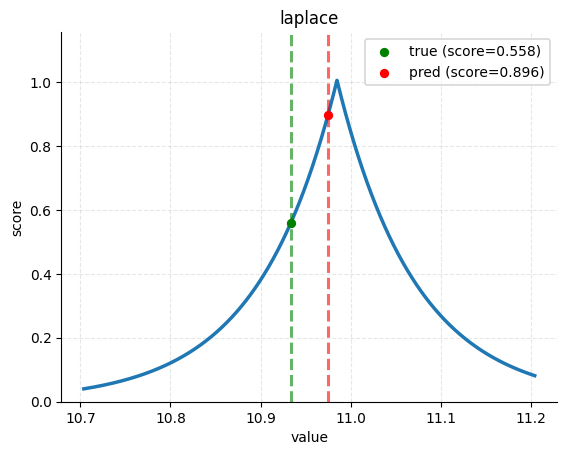

{'pdf_type': 'laplace',
 'true_target': 10.93320029842169,
 'prediction': 10.974582830616383,
 'score_true': 0.5579354802725575,
 'score_pred': 0.8964852003435902,
 'x_range': (10.703891564519036, 11.203891564519036)}

In [12]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],test_y_true,trq_margin_pred)